# Leapfrog Studio

You will implement a quick leapfrog integrator (an example of a *symplectic* integrator, based on a Hamiltonian) and compare it to your second-order Runge Kutta.  Almost everything you need it provided: you only need to add the stepper for your Leapfrog, and the inital conditions for you eccentric orbit (total of ~5 lines).

## Group #: 11
## Members: Ethan Duarte, Snigdha Agasthyaraju, Carolina Collazo, Henry Holland

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def rk2step(y,f,x,h):

    """
    Advances solution by a single rk2 step
    
    PARAMETERS:
    input:
        y -- initial value, scalar;
        f -- function (RHS of ODE);
        x -- starting x.
        h -- stepsize

    RETURNS:
        updated result

        See the assignment sheet for additional details about these
        function parameters.
    """
    
    k1 = h*f(x,y)
    k2 = h*f(x + h, y + k1)
    
    ynew = y + 0.5*(k1 + k2)
    
    return ynew

def leapfrogstep(y,f,x,h):

    """
    Advances solution by a single leapfrog step
    
    PARAMETERS:
    input:
        y -- initial value, scalar;
        f -- function (RHS of ODE);
        x -- starting x.
        h -- stepsize

    RETURNS:
        updated result

        See the assignment sheet for additional details about these
        function parameters.
    """
    
    ## Here it's easier to unpack your y vector, since 
    ## we're going to treat positions and velocities separately

    ## nice example of python slice notation: this is giving me 2 3D vectors from 
    ## the begining and end of my 6D y vector

    ## note that by this logic, f(x,y)[3:] will pull out only the second three elements
    ## from my dydx (i.e. the forces for my gravity problem)

    ## I can also recombine these into a single 6D vector with y = np.concatenate([pos_1, vel_0])
    pos_0,vel_0 = y[:3],y[3:]

    ## YOUR CODE GOES HERE
    vel_half = vel_0 + f(x,y)[3:] * h / 2
    
    pos_1 = pos_0 + vel_half * h
    
    yhalf = np.concatenate([pos_1, vel_half])
    
    vel_1 = vel_half + f(x + h, yhalf)[3:] * h / 2
    
    ynew = np.concatenate([pos_1, vel_1])
    
    return ynew

    
def ode_fixedstep(nstep,f,x0,y0,x1,iinteg=0):

    """
    Solves an ordinary differential equation
    using fixed step size (either RK2
    or Leapfrog).

    PARAMETERS:
    input:
        nstep  : number of steps
        f      : inline function (RHS of ODE)
        x0     : starting x.
        y0     : starting y (scalar).
        x1     : end x.
        iinteg : integrator: 0: RK2
                             1: Leapfrog
                            
    output:
        x      : positions of n+1 steps
        y      : (nstep+1,1) vector of resulting y's
    


    """
    h = (x1-x0)/nstep
    x = np.linspace(x0,x1,nstep+1)

    ## create an array of size nstep x 6, and 
    ## set our initial conditions as the first element
    y = np.zeros((nstep+1,np.size(y0)))
    y[0] = y0
    
    if iinteg == 0:
        for i in range(1,nstep+1):
            y[i] = rk2step(y[i-1],f,x[i-1],h)
    
    if iinteg == 1:
        for i in range(1,nstep+1):
            y[i] = leapfrogstep(y[i-1],f,x[i-1],h)        
        
    return x,y

Let's place a test particle in orbit about the Sun (i.e. a particle with mass $M_{\odot}$), at a distance of $1\rm{AU}$.  As before, we'll work in units where where $G = M_{\odot} = 1\rm{AU}=1$ to make our lives easier.  Remember that in these units, a year is $2\pi$.

In [3]:
def dydx_gravity(t,y_vec):
    """
    The right-hand side of my gravity ODE.  Takes 

    PARAMETERS:
    input:
        t      : time (not needed)
        y_vec  : 6D input vector (x,y,z,vx,vy,vz)                      
    output:
        dydx   : the right-hand side of my diff. eq.
                 i.e. (vx,vy,vz,fx,fy,fz)
    
    """
    ## unpack my vector and calculate the distance r
    ## Note there are cleverer NumPy ways I could do this, 
    ## but this works just fine (and easier to read IMO)

    x,y,z,vx,vy,vz = y_vec
    r = np.sqrt(x**2 + y**2 + z**2)
    
    ## then compute my forces
    fx = -x / r**3
    fy = -y / r**3
    fz = -z / r**3

    ## and return my dydx
    dydx = np.array([vx,vy,vz,fx,fy,fz])

    return dydx
    

## Testing with a Circular Orbit

First, we'll just set up a circular orbit in the X-Y plane.  We'll place it at $x_0=1$, and give it an initial velocity in the $+y$ direction  This is trivial in our system of units: we know that a planet at a radius of $1\rm{AU}$ takes $2\pi$ (or one year) to orbit the Sun, and since the the circumference of that orbit is also $2\pi$, our velocity is just $\vec{v}_0 = (0,1,0)$.  

In [4]:
y0 = np.array([1,0,0,0,1,0])

Now just integrate forward, say for 100 years with `nstep=20000`

In [5]:
t_start = 0
t_end = 100*(2*np.pi)
nstep = 20000

times, ys = ode_fixedstep(nstep,dydx_gravity,t_start,y0,t_end,0)

First plot the relative change in energy here; this should be very similar to the code you turned in for HW01 (albeit simplier!)

In [6]:
## I find it easiest to unpack these into 6 arrays
x,y,z,vx,vy,vz = ys.T

kinetic_energy = 0.5 * (vx**2 + vy**2 + vz**2)
potential_energy = - 1 / np.sqrt(x**2 + y**2 + z**2)
total_energy = kinetic_energy + potential_energy

relative_energy_drift = np.abs((total_energy - total_energy[0]) / total_energy[0])

Text(0.5, 1.0, 'Relative Energy Drift')

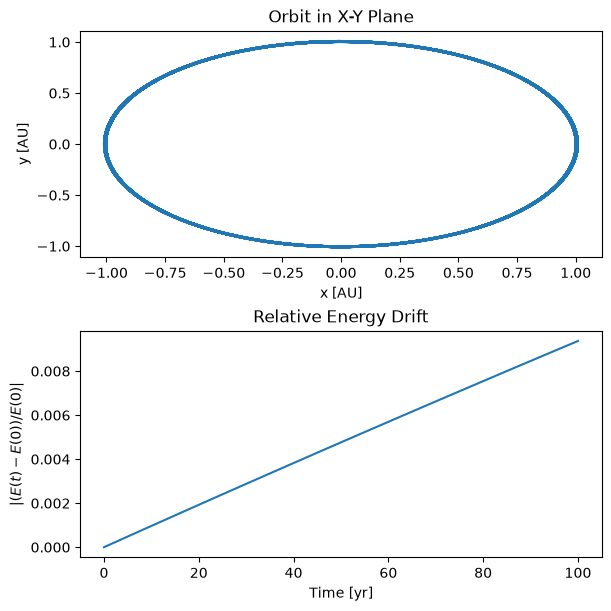

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6),
                               constrained_layout=True)

ax1.plot(x,y)
ax1.set_xlabel('x [AU]')
ax1.set_ylabel(r"y [AU]")
ax1.set_title("Orbit in X-Y Plane")

ax2.plot(times / (2*np.pi),relative_energy_drift)
ax2.set_xlabel('Time [yr]')
ax2.set_ylabel(r"$|(E(t) - E(0)) / E(0)|$")
ax2.set_title("Relative Energy Drift")

## An Eccentric Orbit

Now let's do the same thing again, but on an eccentric orbit.  You can start off your particle much closer (at pericenter) and with a faster velocity.  These are given by:

$$
\begin{aligned}
 r_p   &= r_{\rm circ}(1-e)\\
v_p &= v_{\rm circ}\sqrt{\frac{1+e}{1-e}} 
\end{aligned}
$$

where $r_{\rm circ}$ and $v_{\rm circ}$ are the position and velocities of our circular orbits, respectively.  $e$ is the eccentricity, which is 0 for a circular orbit.  

#### Try recreating your above plot with $e=0.8$ 

In [8]:
## PUT YOUR INITIAL CONDITIONS HERE:
y0 = [0.2, 0, 0, 0, 3, 0]

Text(0.5, 1.0, 'Relative Energy Drift')

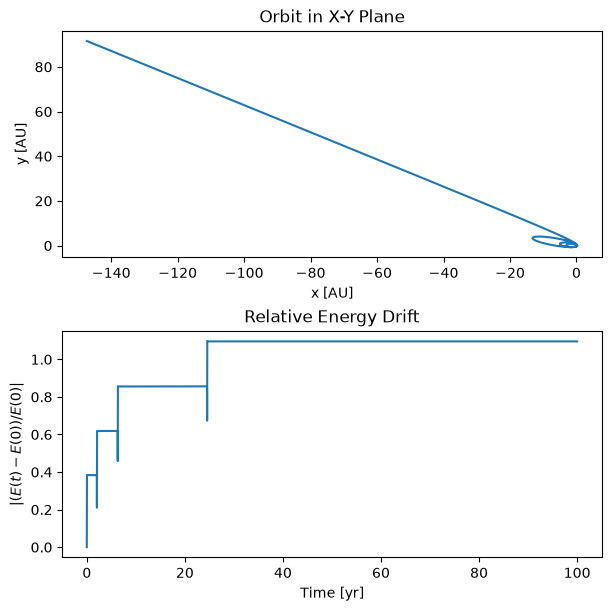

In [9]:
t_start = 0
t_end = 100*(2*np.pi)
nstep = 20000

times, ys = ode_fixedstep(nstep,dydx_gravity,t_start,y0,t_end,0)

## I find it easiest to unpack these into 6 arrays
x,y,z,vx,vy,vz = ys.T

kinetic_energy = 0.5 * (vx**2 + vy**2 + vz**2)
potential_energy = - 1 / np.sqrt(x**2 + y**2 + z**2)
total_energy = kinetic_energy + potential_energy

relative_energy_drift = np.abs((total_energy - total_energy[0]) / total_energy[0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6),
                               constrained_layout=True)

ax1.plot(x,y)
ax1.set_xlabel('x [AU]')
ax1.set_ylabel(r"y [AU]")
ax1.set_title("Orbit in X-Y Plane")

ax2.plot(times / (2*np.pi),relative_energy_drift)
ax2.set_xlabel('Time [yr]')
ax2.set_ylabel(r"$|(E(t) - E(0)) / E(0)|$")
ax2.set_title("Relative Energy Drift")

Hmm, not good!  The energy is clearly drifting away and my planet is clearly moving outwards, eventually becoming unbound from the star.  Seems like a perfect job for a symplectic integrator

### Implement the 2nd-order Leapfrog integrator in the above cell at the top of this notebook.  Does this improve energy conservation and physics behaivor using the same number of steps?

Text(0.5, 1.0, 'Relative Energy Drift')

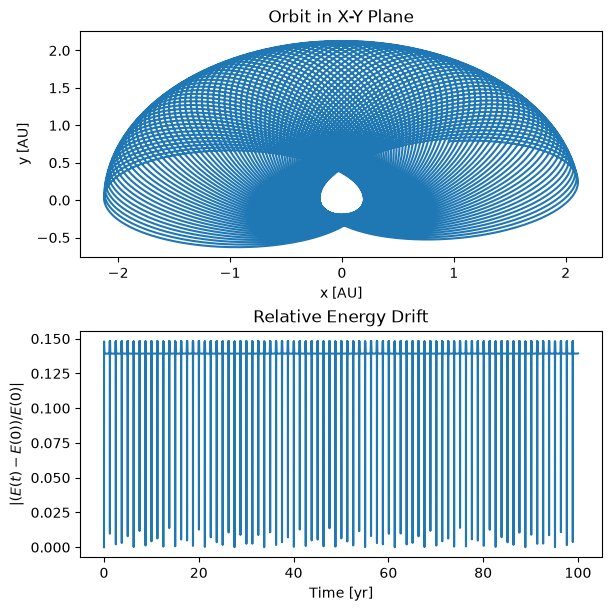

In [10]:
e = 0.8

y0 = np.array([1*(1-e),0,0,0,1*np.sqrt((1+e)/(1-e)),0])

t_start = 0
t_end = 100*(2*np.pi)
nstep = 20000

times, ys = ode_fixedstep(nstep,dydx_gravity,t_start,y0,t_end,1)

## I find it easiest to unpack these into 6 arrays
x,y,z,vx,vy,vz = ys.T

kinetic_energy = 0.5 * (vx**2 + vy**2 + vz**2)
potential_energy = - 1 / np.sqrt(x**2 + y**2 + z**2)
total_energy = kinetic_energy + potential_energy

relative_energy_drift = np.abs((total_energy - total_energy[0]) / total_energy[0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6),
                               constrained_layout=True)

ax1.plot(x,y)
ax1.set_xlabel('x [AU]')
ax1.set_ylabel(r"y [AU]")
ax1.set_title("Orbit in X-Y Plane")

ax2.plot(times / (2*np.pi),relative_energy_drift)
ax2.set_xlabel('Time [yr]')
ax2.set_ylabel(r"$|(E(t) - E(0)) / E(0)|$")
ax2.set_title("Relative Energy Drift")